# Colon Xenium slide QC summary

## Goal

Combine exactly six validated region bundles from one run label and execution mode. The summary compares technical QC across Mouse_1 and Mouse_2 at top, middle, and bottom positions without treating cells as biological replicates.

## Setup

HPC paths are defaults. Local validation injects D-drive paths and `LOCAL_SUBSET`. No package installation or writes outside `colon_analysis` are permitted.

In [1]:
EXECUTION_MODE <- toupper(Sys.getenv("COLON_QC_MODE", "FULL_HPC"))
PROJECT_ROOT <- Sys.getenv("COLON_PROJECT_ROOT", "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium")
PIPELINE_REPO <- Sys.getenv("COLON_PIPELINE_REPO", file.path(PROJECT_ROOT, "colon_analysis", "YNH_Xenium_Colon"))
RUN_LABEL <- Sys.getenv("COLON_RUN_LABEL", "colon_qc_hpc")
RUN_ROOT <- Sys.getenv("COLON_RUN_ROOT", file.path(PROJECT_ROOT, "colon_analysis", "colon_qc_outputs", RUN_LABEL))
TEMP_ROOT <- Sys.getenv("COLON_TEMP_ROOT", file.path(PROJECT_ROOT, "colon_analysis", "tmp", RUN_LABEL))
dir.create(TEMP_ROOT, recursive = TRUE, showWarnings = FALSE)
Sys.setenv(TMPDIR = TEMP_ROOT, TMP = TEMP_ROOT, TEMP = TEMP_ROOT)
source(file.path(PIPELINE_REPO, "R", "source.R"))
regions <- expected_colon_regions()

## Inputs and integrity

Require Region_1 through Region_6, reject missing/duplicate regions and mixed run labels or modes, then reload every saved sparse object and table.

In [2]:
manifest <- utils::read.delim(file.path(PIPELINE_REPO, "config", "colon_sample_manifest.tsv"), check.names = FALSE)
validate_sample_manifest(manifest, regions)
slide_data <- read_colon_slide_qc_outputs(RUN_ROOT, expected_regions = regions, run_label = RUN_LABEL, execution_mode = EXECUTION_MODE)
stopifnot(identical(slide_data$coverage$region_id, regions))

$valid
[1] TRUE

$issues
character(0)

Loading required namespace: Matrix



## Cell QC

Summarize fixed-bound pass fractions and review flags. `primary_include` is never redefined at slide level. Region readiness is derived from current evidence rather than inherited anchor or sensitivity labels.

In [3]:
slide_summary <- summarise_slide_qc(slide_data)
position_summary <- summarise_colon_mouse_position(slide_summary$section_summary, manifest)
position_summary$within_mouse
position_summary$matched_position

region_id,mouse_id,position,input_cells,core_qc_pass,core_qc_fail,review_flagged,nucleus_missing,multiple_nuclei,segmentation_multiplet,area_outlier,high_control,cells_deleted,run_label,execution_mode,core_pass_fraction,review_fraction
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>
Region_1,Mouse_1,top,150496,145256,5240,34558,25195,4628,4906,2162,6,0,colon_qc_hpc,FULL_HPC,0.9651818,0.2296274
Region_2,Mouse_1,middle,234658,226187,8471,56224,38558,11354,11750,3556,5,0,colon_qc_hpc,FULL_HPC,0.9639007,0.2395998
Region_3,Mouse_1,bottom,235415,226615,8800,58286,40206,12056,12691,4062,2,0,colon_qc_hpc,FULL_HPC,0.9626192,0.2475883
Region_4,Mouse_2,top,91297,86447,4850,20568,12367,4824,5089,1849,1,0,colon_qc_hpc,FULL_HPC,0.9468767,0.2252867
Region_5,Mouse_2,middle,103859,98881,4978,25830,16814,5201,5440,1979,13,0,colon_qc_hpc,FULL_HPC,0.9520696,0.2487026
Region_6,Mouse_2,bottom,138752,133195,5557,21947,10744,6704,7075,2187,25,0,colon_qc_hpc,FULL_HPC,0.9599501,0.1581743


position,input_cells,core_qc_pass,core_pass_fraction,n_mice
<chr>,<dbl>,<dbl>,<dbl>,<int>
top,120896.5,115851.5,0.9560292,2
middle,169258.5,162534.0,0.9579851,2
bottom,187083.5,179905.0,0.9612847,2


## Outputs and checks

Save combined tables, descriptive within-mouse and matched-position summaries, readiness gates, figures, session information, and a reloadable slide object.

In [4]:
summary_output_dir <- file.path(RUN_ROOT, "slide_summary")
result <- write_colon_slide_qc_bundle(PROJECT_ROOT, summary_output_dir, RUN_LABEL, EXECUTION_MODE, slide_data, slide_summary, position_summary)
stopifnot(validate_colon_slide_qc_bundle(summary_output_dir, expected_regions = regions))
result

run_label,execution_mode,regions,overall_status
<chr>,<chr>,<int>,<chr>
colon_qc_hpc,FULL_HPC,6,PASS


In [5]:
slide_plots <- plot_slide_qc(slide_data, slide_summary)

In [6]:
names(slide_plots)

[1] "cell_yield" "counts"     "features"   "review"     "flags"     
[6] "thresholds"

In [7]:
options(repr.plot.width=7, repr.plot.height=5)

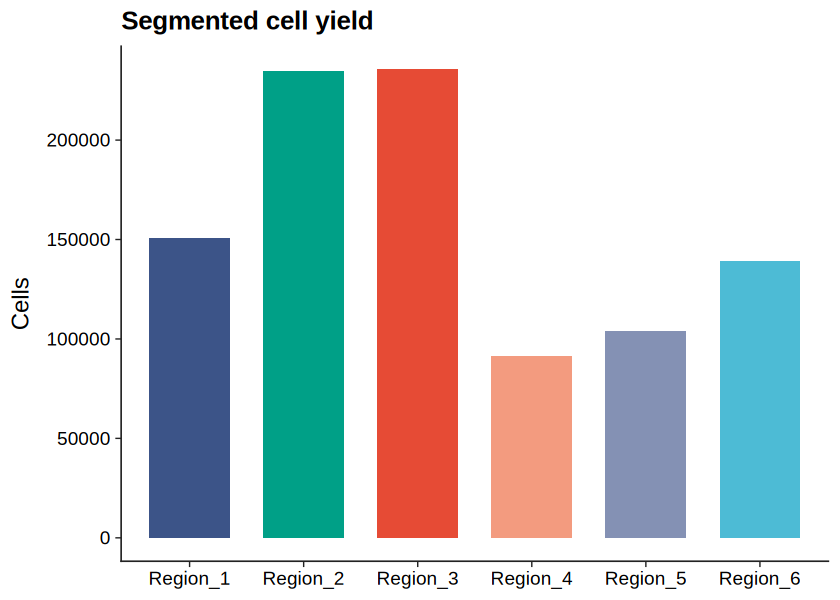

In [8]:
slide_plots$cell_yield

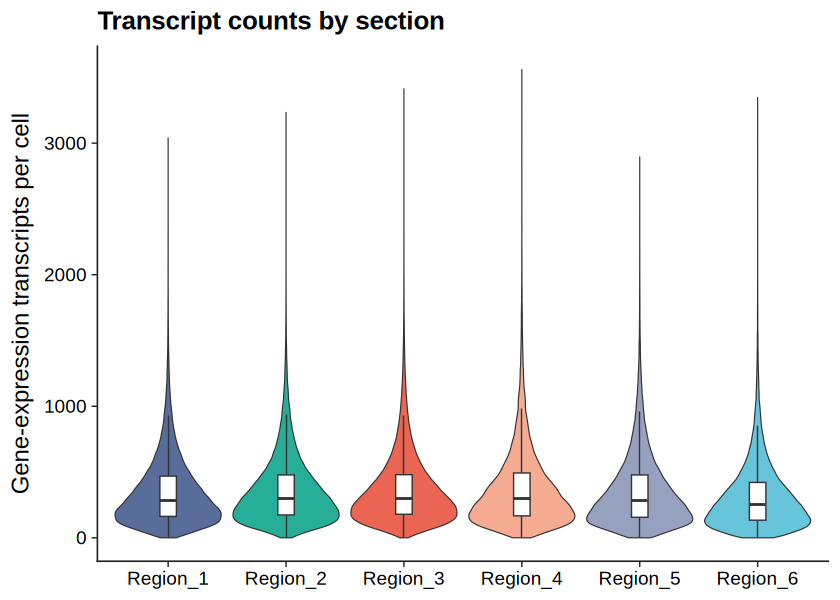

In [9]:
slide_plots$counts

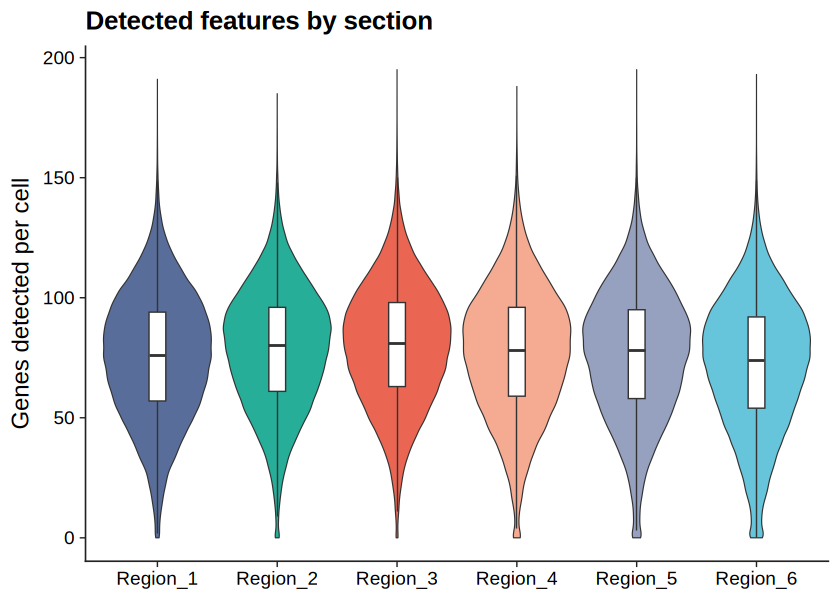

In [10]:
slide_plots$features

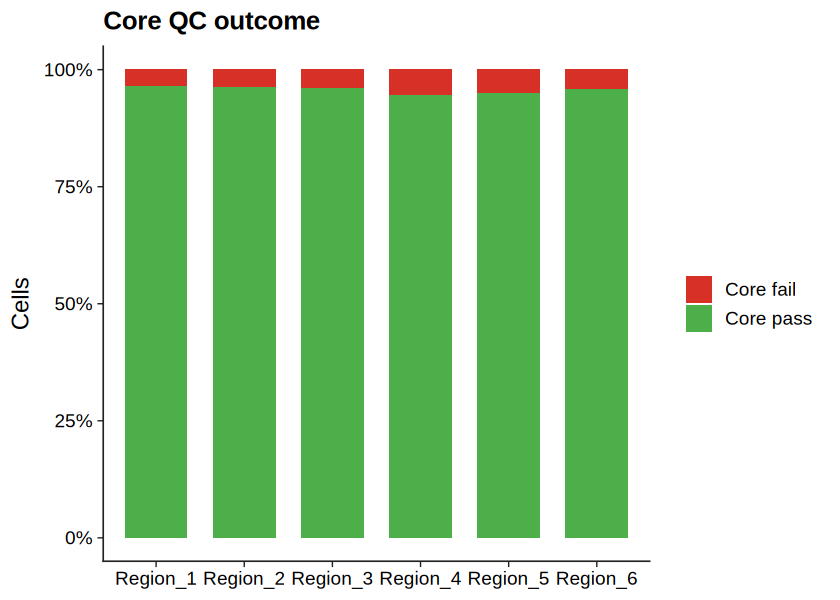

In [11]:
slide_plots$review

In [12]:
options(repr.plot.width=16, repr.plot.height=8)

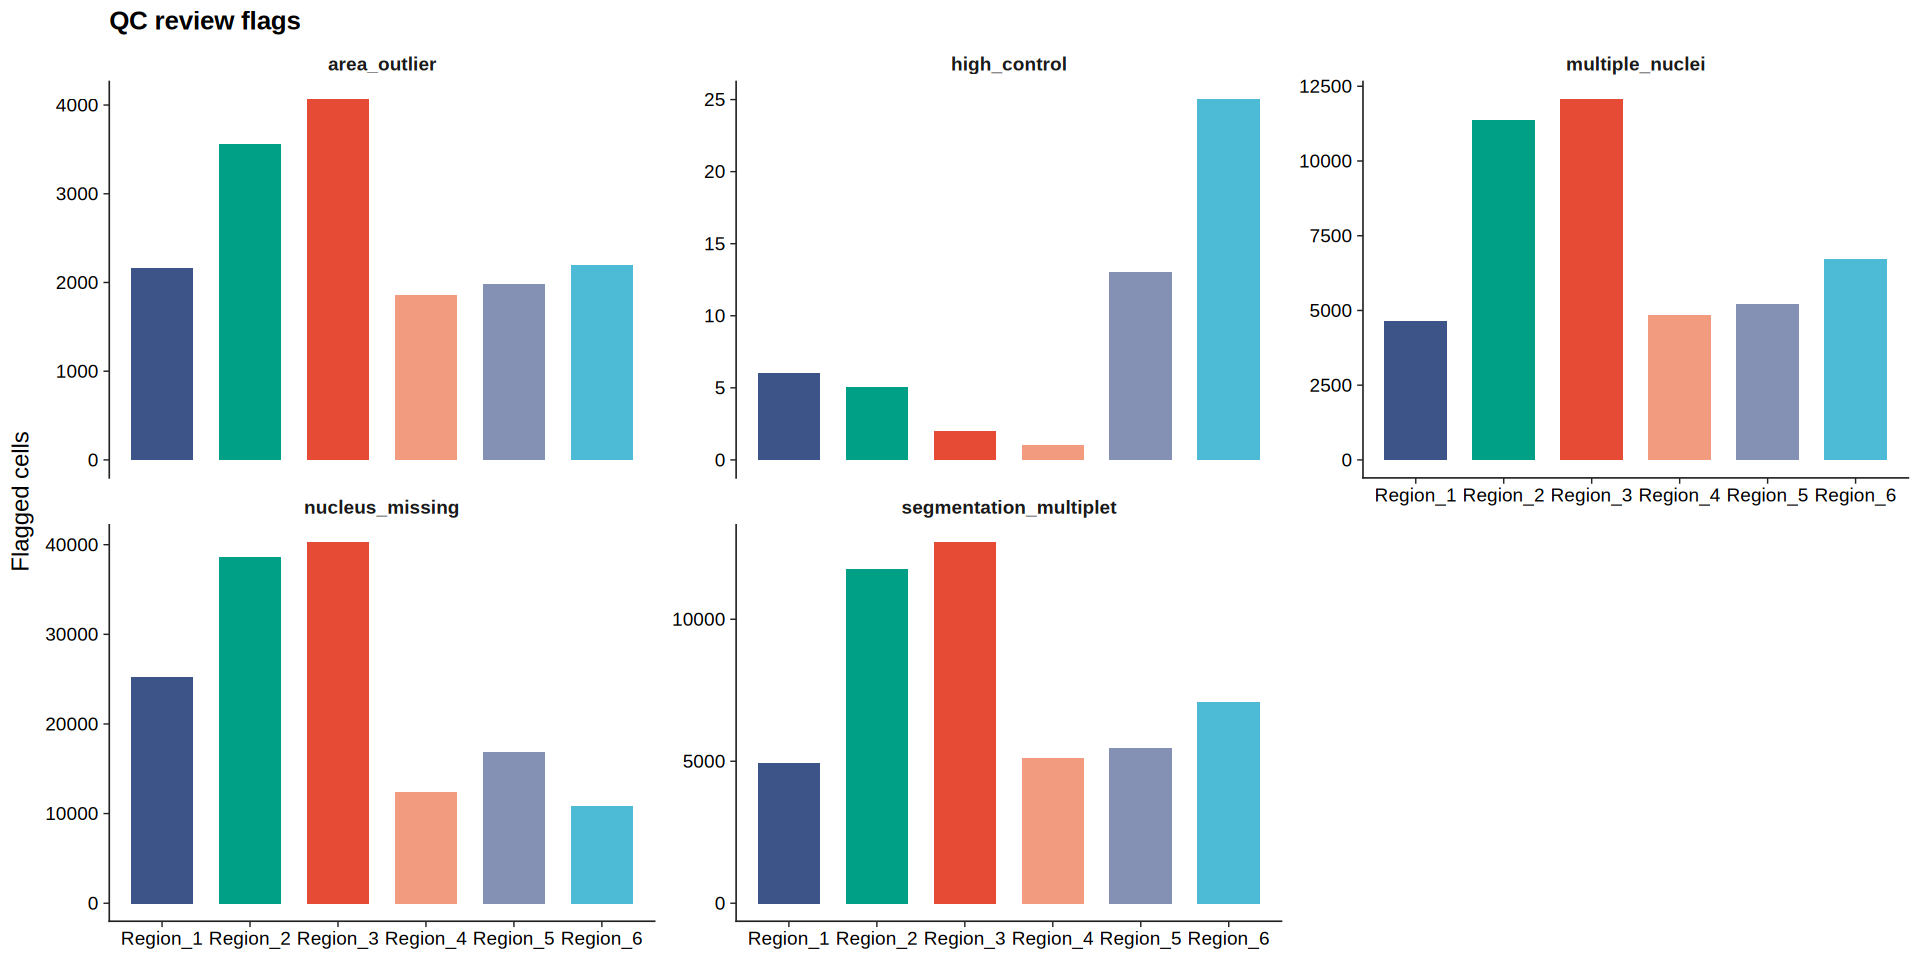

In [13]:
slide_plots$flags

In [14]:
options(repr.plot.width=11, repr.plot.height=5.5)

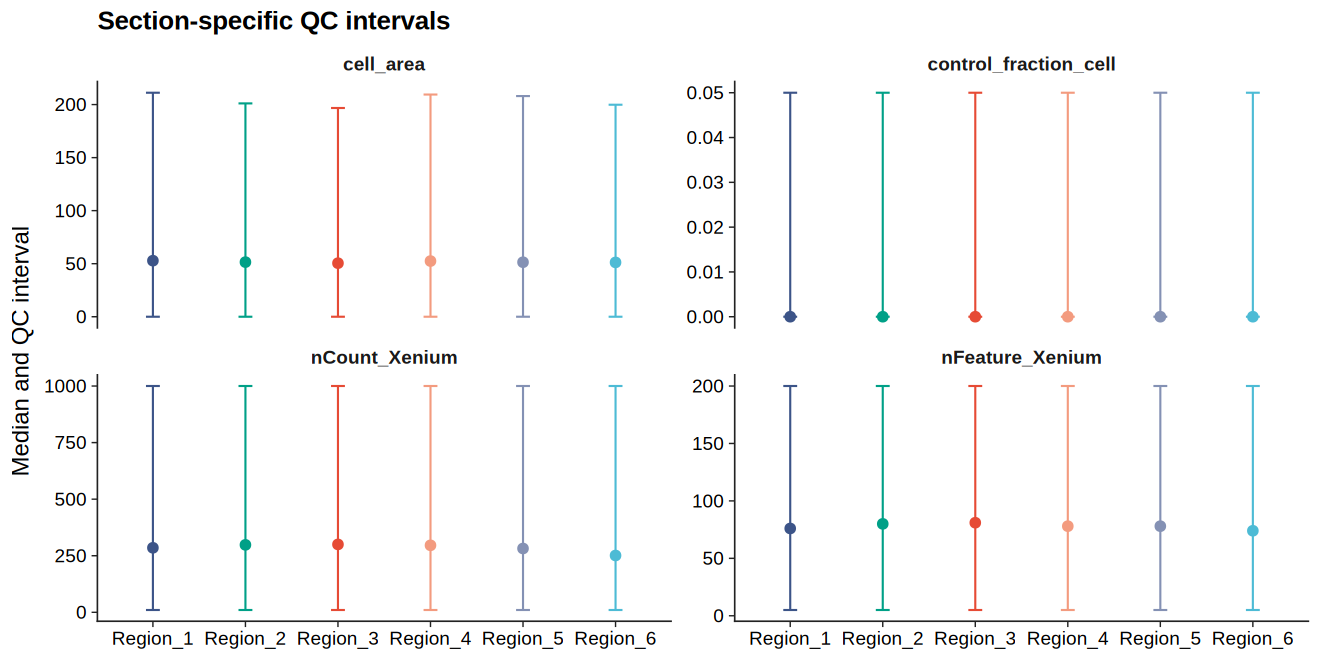

In [15]:
slide_plots$thresholds

## Next steps

Use full-HPC evidence for the final QC decision. With only two mice, anatomical-position results are descriptive. The adipose-derived eosinophil lists remain hypotheses (`AT-short-like` and `AT-long-like`) until colon-specific coherence and identity checks are completed in a later, study-specific analysis stage.